# Results Viewer

### Imports

In [29]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from cr3bp import (
    create_earth_moon_system,
    plot_trajectory,
    decision_to_state0,
    evaluate,
    animate_trajectory,
    ciruclar_orbit_trajectory_moon,
    jacobi_integral,
    file_path
    )

### Initialize the System / Problem

In [30]:
# Create the Earth-Moon system using the cr3bp module
em = create_earth_moon_system()
em.info()

CR3BP System Information:
  Primary 1 mass: 5.972e+24 kg
  Primary 2 mass: 7.342e+22 kg
  Primary 1 radius: 6.371e+06 m
  Primary 2 radius: 1.737e+06 m
  Total mass: 6.045e+24 kg
  Distance: 3.844e+08 m (384400.0 km)
  Mass parameter μ: 0.012145

Characteristic scales:
  Length (l*): 3.844e+08 m (384400.0 km)
  Time (t*): 3.752e+05 s (4.343 days)
  Velocity (v*): 1.025e+03 m/s (1.025 km/s)
  Acceleration (a*): 2.731e-03 m/s^2
  Period: 27.285 days


In [31]:
# Define the LEO and LMO altitudes in meters
leo_alt_m=463e3
lmo_alt_m=100e3

## Results

In [32]:
optimals = np.load(f"{file_path}/optimals_iteration3.npy")

In [33]:
print(optimals)

[3.9836392  3.02605609 0.1045412  0.77454986]


In [34]:
optimal_theta = optimals[0]
optimal_delta_v = optimals[1]
optimal_delta_v_angle = optimals[2]
optimal_tof = optimals[3]
print(f"Optimal Theta from Grid Search: {optimal_theta:.4f} rad")
print(f"Optimal Delta_v from Grid Search: {optimal_delta_v*em.v_star*1e-3:.4f} km/s")
print(f"Optimal Delta_v Angle from Grid Search: {optimal_delta_v_angle:.4f} rad")
print(f"Optimal Time of Flight from Grid Search: {optimal_tof * em.t_star / 86400:.4f} days")

Optimal Theta from Grid Search: 3.9836 rad
Optimal Delta_v from Grid Search: 3.1003 km/s
Optimal Delta_v Angle from Grid Search: 0.1045 rad
Optimal Time of Flight from Grid Search: 3.3635 days


In [35]:
print(f"Optimal Delta_v Angle: {optimal_delta_v_angle * 180 / np.pi:.2f} degrees")
print(f"Optimal Theta: {optimal_theta * 180 / np.pi:.2f} degrees")

Optimal Delta_v Angle: 5.99 degrees
Optimal Theta: 228.25 degrees


## Transition Trajectory

In [36]:
x0 = np.array(optimals)
state0 = decision_to_state0(em, x0, leo_alt_m)

In [37]:
tof = x0[3]
t_span = (0,tof)
n_points = 1000
#t_eval = np.linspace(0, tof, n_points)
t_eval = np.arange(0, tof, 1e-3) # Starts at 0, ends at tof, with a step of 1e-3 seconds
states, ts, sol = em.solve(state0, t_span, t_eval)
states_rocket_inertial = em.trajectory_rotating_to_inertial(states, t_eval)

In [38]:
constraint_value, objective_value = evaluate(em, x0, leo_alt_m=leo_alt_m, lmo_alt_m=lmo_alt_m)

### Plot

In [39]:
pos_f = states[:,-1][0:3]
#print(f"Rocket Final Pos in Rotating Frame (normalized units): {pos_f}")
print(f"Distance from moon : {1e-3*(constraint_value*em.l_star + lmo_alt_m):.0f} km")
print(f"Distance from LMO of 100 km : {constraint_value*em.l_star * 1e-3:.0f} km")
print(f"Total Delta_v required : {objective_value*em.v_star * 1e-3:.3f} km/s")

Distance from moon : 101 km
Distance from LMO of 100 km : 1 km
Total Delta_v required : 3.980 km/s


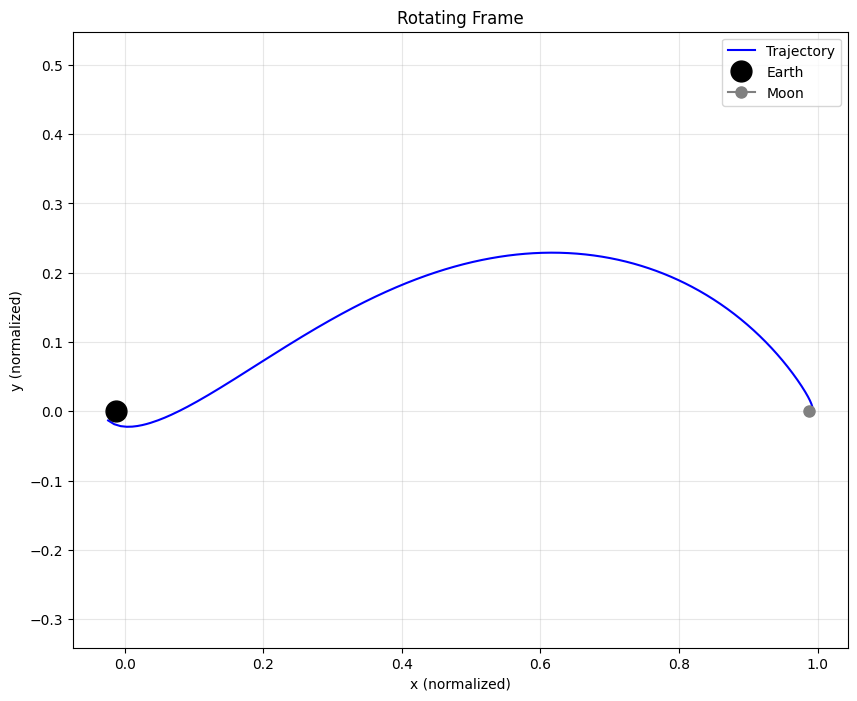

In [40]:
plot_trajectory(states, em.mu, t_eval, frame="Rotating")

In [41]:
import matplotlib.ticker as ticker
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


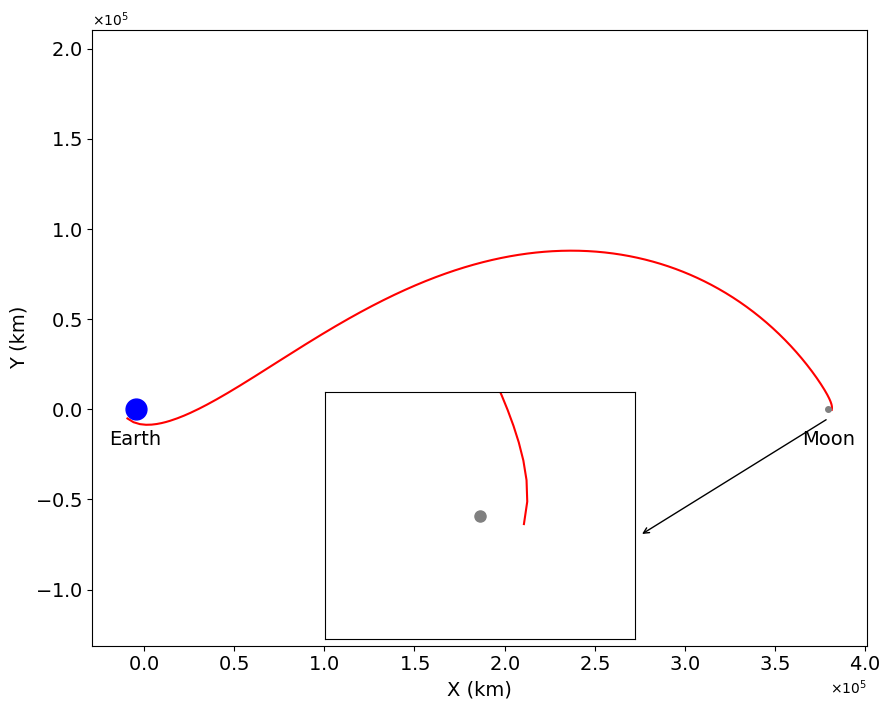

In [42]:
fs = 14  # fontsize — change this one value to scale everything

fig, ax = plt.subplots(figsize=(10, 8))

# Plot trajectory
ax.plot(states[0, :]*em.l_star*1e-3, states[1, :]*em.l_star*1e-3, 'r-', linewidth=1.5)

# Plot primaries
earth_x = -em.mu*em.l_star*1e-3
moon_x = (1-em.mu)*em.l_star*1e-3

ax.plot(earth_x, 0, 'bo', markersize=15)
ax.plot(moon_x, 0, 'gray', marker='o', markersize=4)

ax.annotate('Earth', xy=(earth_x, 0), xytext=(earth_x, -20000), ha='center', fontsize=fs)
ax.annotate('Moon', xy=(moon_x, 0), xytext=(moon_x, -20000), ha='center', fontsize=fs)

# Scientific notation offset
for axis in [ax.xaxis, ax.yaxis]:
    axis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='both', scilimits=(5,5))

ax.set_xlabel('X (km)', fontsize=fs)
ax.set_ylabel('Y (km)', fontsize=fs)
ax.tick_params(axis='both', labelsize=fs)

# --- Inset ---
axins = inset_axes(ax, width='40%', height='40%', loc='lower center')

axins.plot(states[0, :]*em.l_star*1e-3, states[1, :]*em.l_star*1e-3, 'r-', linewidth=1.5)
axins.plot(earth_x, 0, 'bo', markersize=15)
axins.plot(moon_x, 0, 'gray', marker='o', markersize=8)

# Zoom window around moon - adjust these
zoom = 5000  # km
axins.set_xlim(moon_x - zoom, moon_x + zoom)
axins.set_ylim(-zoom, zoom)
axins.set_aspect('equal', adjustable='datalim')
axins.set_xticks([])
axins.set_yticks([])

ax.annotate('', 
            xy=(275000, -70000),
            xytext=(moon_x, -zoom),
            arrowprops=dict(arrowstyle='->', color='black'))

plt.draw()
ax.set_aspect('equal', adjustable='datalim')

plt.show()

## Low Lunar Orbit

In [43]:
moon_f = np.array([1-em.mu,0,0,0,0,0])
moon_f_inertial = em.rotating_to_inertial(moon_f,tof)

tof_llo = 1.5
t_eval_llo = np.arange(tof, tof+tof_llo, 1e-3) # Starts at the end of the previous trajectory, 
#ends at tof+tof_llo, with a step of 1e-3 seconds

states_llo_inertial = ciruclar_orbit_trajectory_moon(em, states_rocket_inertial[:,-1], moon_f_inertial, tof_llo, num_points=len(t_eval_llo))
states_llo_rotating = em.trajectory_inertial_to_rotating(states_llo_inertial, t_eval_llo)

### Plot

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


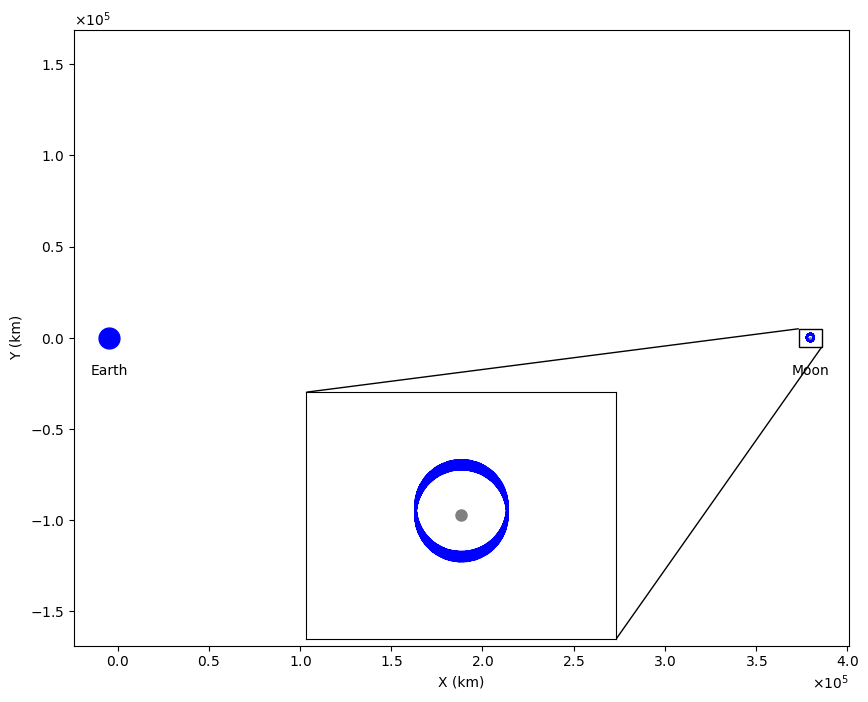

In [44]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

fig, ax = plt.subplots(figsize=(10, 8))

# Plot trajectory
ax.plot(states_llo_rotating[0, :]*em.l_star*1e-3, states_llo_rotating[1, :]*em.l_star*1e-3, 'b-', linewidth=1.5)

# Plot primaries
earth_x = -em.mu*em.l_star*1e-3
moon_x = (1-em.mu)*em.l_star*1e-3

ax.plot(earth_x, 0, 'bo', markersize=15)
ax.plot(moon_x, 0, 'gray', marker='o', markersize=1)

ax.annotate('Earth', xy=(earth_x, 0), xytext=(earth_x, -20000), ha='center')
ax.annotate('Moon', xy=(moon_x, 0), xytext=(moon_x, -20000), ha='center')

# Scientific notation offset
for axis in [ax.xaxis, ax.yaxis]:
    axis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='both', scilimits=(5,5))

ax.set_xlabel('X (km)')
ax.set_ylabel('Y (km)')

# --- Inset ---
axins = inset_axes(ax, width='40%', height='40%', loc='lower center')

axins.plot(states_llo_rotating[0, :]*em.l_star*1e-3, states_llo_rotating[1, :]*em.l_star*1e-3, 'b-', linewidth=1.5)
axins.plot(earth_x, 0, 'bo', markersize=15)
axins.plot(moon_x, 0, 'gray', marker='o', markersize=8)

# Zoom window around moon - adjust these
zoom = 5000  # km
axins.set_xlim(moon_x - zoom, moon_x + zoom)
axins.set_ylim(-zoom, zoom)
axins.set_aspect('equal', adjustable='datalim')
axins.set_xticks([])
axins.set_yticks([])

# Draw box connecting inset to main plot
mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="black")

plt.draw()
ax.set_aspect('equal', adjustable='datalim')

plt.show()

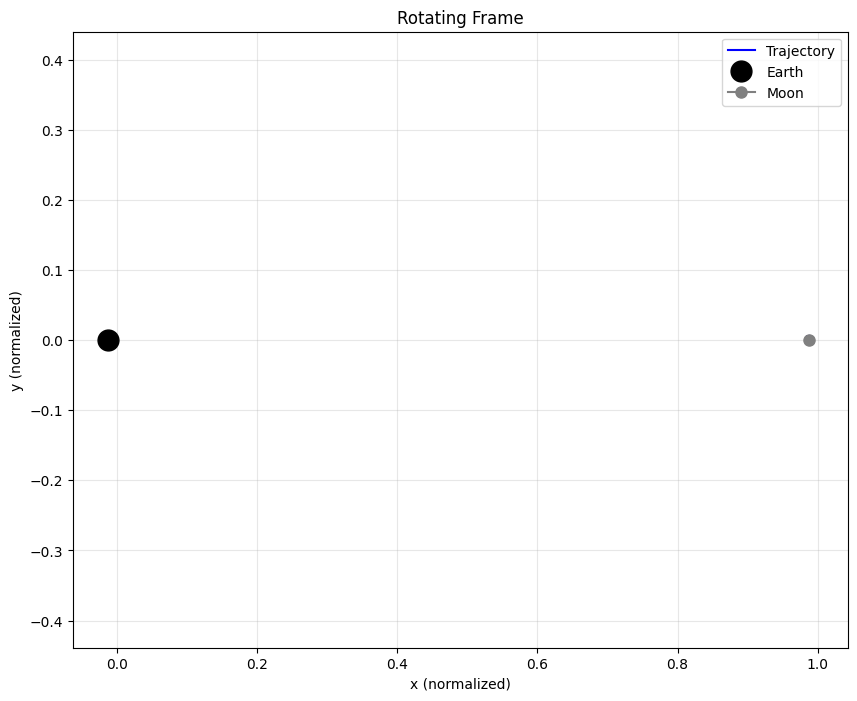

In [45]:
plot_trajectory(states_llo_rotating, em.mu, t_eval_llo, frame="Rotating")

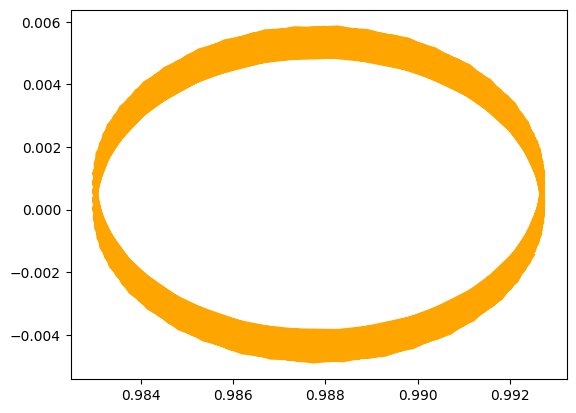

In [46]:
plt.plot(states_llo_rotating[0,:], states_llo_rotating[1,:], label="LLMO Orbit", color="orange")

#### Check stability by integrating

In [47]:
state1 = states_llo_rotating[:,0]
print(state1)

[ 0.9925249  -0.00144367  0.         -0.00144367 -0.9925249   0.        ]


In [48]:
#t_eval = np.linspace(0, tof, n_points)
t_eval = np.arange(0, tof, 1e-3) # Starts at 0, ends at tof, with a step of 1e-3 seconds
states2, ts, sol = em.solve(state1, t_span, t_eval)

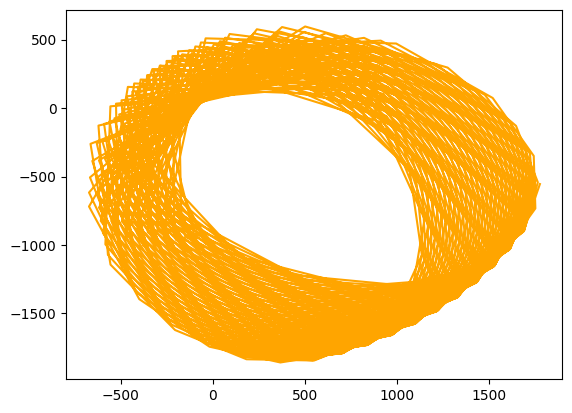

In [49]:
plt.plot(states2[0,:]*em.l_star*1e-3 - 379750, states2[1,:]*em.l_star*1e-3, label="LLMO Orbit", color="orange")

## Combine TLI and LMO

In [50]:
states_full = np.concatenate((states, states_llo_rotating), axis=1) # Concatenate the two trajectories along the time axis (columns)
t_full = np.arange(0, tof+tof_llo, 1e-3) # Starts at 0, ends at tof+tof_llo, with a step of 1e-3 seconds

### Plot

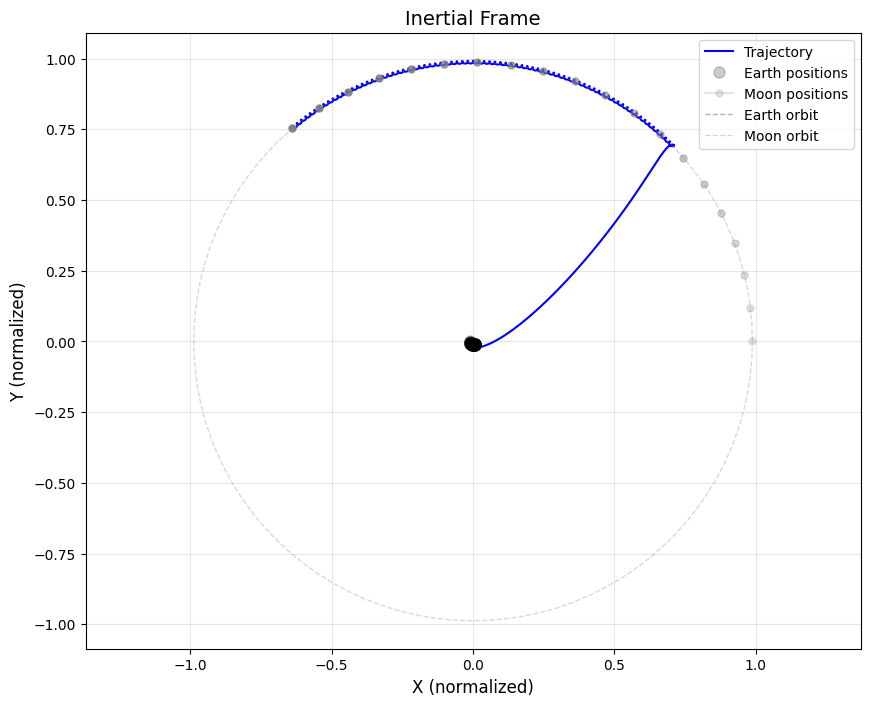

In [51]:
plot_trajectory(states_full, em.mu, t_full, frame="Inertial")

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


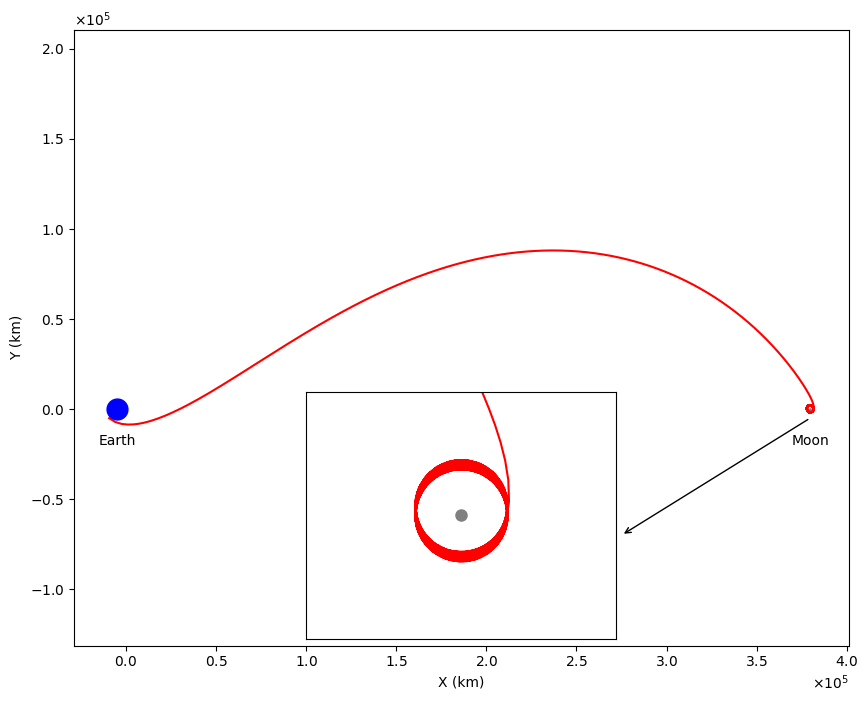

In [69]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

fig, ax = plt.subplots(figsize=(10, 8))

# Plot trajectory
ax.plot(states_full[0, :]*em.l_star*1e-3, states_full[1, :]*em.l_star*1e-3, 'r-', linewidth=1.5)

# Plot primaries
earth_x = -em.mu*em.l_star*1e-3
moon_x = (1-em.mu)*em.l_star*1e-3

ax.plot(earth_x, 0, 'bo', markersize=15)
ax.plot(moon_x, 0, 'gray', marker='o', markersize=1)

ax.annotate('Earth', xy=(earth_x, 0), xytext=(earth_x, -20000), ha='center')
ax.annotate('Moon', xy=(moon_x, 0), xytext=(moon_x, -20000), ha='center')

# Scientific notation offset
for axis in [ax.xaxis, ax.yaxis]:
    axis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='both', scilimits=(5,5))

ax.set_xlabel('X (km)')
ax.set_ylabel('Y (km)')

# --- Inset ---
axins = inset_axes(ax, width='40%', height='40%', loc='lower center')

axins.plot(states_full[0, :]*em.l_star*1e-3, states_full[1, :]*em.l_star*1e-3, 'r-', linewidth=1.5)
axins.plot(earth_x, 0, 'bo', markersize=15)
axins.plot(moon_x, 0, 'gray', marker='o', markersize=8)

# Zoom window around moon - adjust these
zoom = 5000  # km
axins.set_xlim(moon_x - zoom, moon_x + zoom)
axins.set_ylim(-zoom, zoom)
axins.set_aspect('equal', adjustable='datalim')
axins.set_xticks([])
axins.set_yticks([])

ax.annotate('', 
            xy=(275000, -70000),
            xytext=(moon_x, -zoom),
            arrowprops=dict(arrowstyle='->', color='black'))

plt.draw()
ax.set_aspect('equal', adjustable='datalim')

plt.show()

## Convergence Test

Use the Jacobi integral (constant of motion) to check the convergence of the integration

In [53]:
jacobi_integral(em, state0)

np.float64(2.100287240863139)

In [57]:
print(em.v_star)

1024.5293671698962


Min Jacobi Integral: 2.100287240716
max Jacobi Integral: 2.100287240863
Difference between max and min Jacobi Integral: 1.467554966439e-10
STD of Jacobi Integral: 4.943203315262e-12


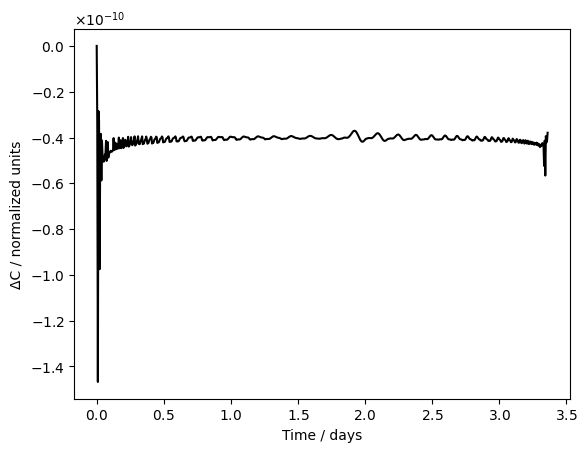

In [66]:
jacobi_integral_values = jacobi_integral(em, states)

fig, ax = plt.subplots()
ax.plot(t_eval*em.t_star/86400, (jacobi_integral_values-jacobi_integral_values[0]), label="Jacobi Integral", color="black")

for axis in [ax.xaxis, ax.yaxis]:
    axis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='both', scilimits=(5,1))

ax.set_xlabel("Time / days")
ax.set_ylabel("ΔC / normalized units")
#ax.set_title("Jacobi Integral over Time")


print(f"Min Jacobi Integral: {np.min(jacobi_integral_values):.12f}")
print(f"max Jacobi Integral: {np.max(jacobi_integral_values):.12f}")
diff = np.max(jacobi_integral_values) - np.min(jacobi_integral_values)
print(f"Difference between max and min Jacobi Integral: {diff:.12e}")
print(f"STD of Jacobi Integral: {np.std(jacobi_integral_values):.12e}")

## Load Dataframe

In [55]:
df = np.load(f"{file_path}/optimals_iteration3_df.npy", allow_pickle=True)
df = pd.DataFrame(df, columns=["theta", "delta_v", "delta_v_angle", "tof", "objective_value", "distance_to_lmo"])
df['distance_to_lmo'] = abs(df['distance_to_lmo'] * em.l_star * 1e-3)
df.sort_values(by='objective_value', inplace=True)
optimals = df.iloc[0][0:4].tolist()
print(df)

       theta   delta_v  delta_v_angle       tof  objective_value  \
0   3.983639  3.026056       0.104541  0.774550         3.885171   
1   3.988314  3.024844       0.101269  0.777458         4.032910   
2   3.972420  3.027268       0.104214  0.757098         4.261039   
3   3.978030  3.026056       0.102905  0.764370         4.445036   
4   3.976160  3.026056       0.103560  0.762916         4.715892   
5   3.977095  3.026056       0.104541  0.768733         4.723666   
6   3.981769  3.024844       0.103232  0.771641         4.978247   
7   3.975225  3.024844       0.099306  0.760007         5.177077   
8   3.975225  3.024844       0.101269  0.765824         5.318447   
9   3.974290  3.024844       0.102251  0.762916         5.451874   
10  3.974290  3.024844       0.103232  0.767278         5.519395   
11  3.978030  3.023632       0.104868  0.777458         5.952021   
12  3.971485  3.022420       0.103887  0.774550         6.652880   

    distance_to_lmo  
0          0.534128  
1  

## Animate

In [56]:
animate = 0
if animate == 1:
    anim = animate_trajectory(em, states_full, t_full, frame='inertial', trail_length=2000)
    from IPython.display import HTML
    HTML(anim.to_html5_video())
    anim.save('trajectory_animation.mp4', writer='ffmpeg', fps=30, dpi=150)